# 01 — Data Audit and Exploratory Data Analysis

## Explainable E-Commerce Recommender System

In this notebook, we inspect the Retailrocket e-commerce event data, assess its structure and quality, and conduct initial exploratory analysis of user behaviors including views, add-to-cart actions, and transactions.

**Main objectives:**
- Load `events.csv` and `category_tree.csv`
- Examine dataset dimensions, data types, missing values, and duplicates
- Analyze the distribution of user interaction events
- Explore temporal patterns and user–item interaction characteristics
- Produce clean audit outputs for subsequent feature engineering and recommendation modeling

In [1]:
# Purpose: Import required libraries and configure display settings for data analysis.

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42

In [2]:
# Purpose: Define project paths and verify that the required raw data files are available.

project_root = Path.cwd().parent

raw_data_dir = project_root / "data" / "raw"
processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"
models_dir = project_root / "outputs" / "models"

for directory in [processed_data_dir, figures_dir, tables_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

events_path = raw_data_dir / "events.csv"
category_tree_path = raw_data_dir / "category_tree.csv"

print(f"Project root: {project_root}")
print(f"\nEvents file exists: {events_path.exists()}")
print(f"Category tree file exists: {category_tree_path.exists()}")

Project root: F:\ecommerce-recommender-xai

Events file exists: True
Category tree file exists: True


In [3]:
# Purpose: Load the raw event and product-category hierarchy datasets into pandas DataFrames.

events_df = pd.read_csv(events_path)

category_tree_df = pd.read_csv(category_tree_path)

print("Events dataset shape:", events_df.shape)
print("Category tree dataset shape:", category_tree_df.shape)

Events dataset shape: (2756101, 5)
Category tree dataset shape: (1669, 2)


In [4]:
# Purpose: Display the first five records of each dataset to understand their columns and structure.

print("Events dataset — first five rows:")
display(events_df.head())

print("\nCategory tree dataset — first five rows:")
display(category_tree_df.head())

Events dataset — first five rows:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN



Category tree dataset — first five rows:


,categoryid,parentid
0,1016,213.000
1,809,169.000
2,570,9.000
3,1691,885.000
4,536,"1,691.000"


In [5]:
# Purpose: Inspect column names, data types, and non-null counts in the two raw datasets.

print("Events dataset information:")
events_df.info()

print("\n" + "=" * 70 + "\n")

print("Category tree dataset information:")
category_tree_df.info()

Events dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


Category tree dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [6]:
# Purpose: Quantify missing values and exact duplicate rows to assess raw data quality.

events_missing = pd.DataFrame({
    "missing_count": events_df.isna().sum(),
    "missing_percentage": (events_df.isna().mean() * 100).round(2)
})

category_missing = pd.DataFrame({
    "missing_count": category_tree_df.isna().sum(),
    "missing_percentage": (category_tree_df.isna().mean() * 100).round(2)
})

print("Missing values — events dataset:")
display(events_missing)

print("\nMissing values — category tree dataset:")
display(category_missing)

print(f"\nExact duplicate rows in events dataset: {events_df.duplicated().sum():,}")
print(f"Exact duplicate rows in category tree dataset: {category_tree_df.duplicated().sum():,}")

Missing values — events dataset:


,missing_count,missing_percentage
timestamp,0,0.000
visitorid,0,0.000
event,0,0.000
itemid,0,0.000
transactionid,2733644,99.190



Missing values — category tree dataset:


,missing_count,missing_percentage
categoryid,0,0.000
parentid,25,1.500



Exact duplicate rows in events dataset: 460
Exact duplicate rows in category tree dataset: 0


In [7]:
# Purpose: Count and calculate the proportion of each user interaction event type.

event_distribution = (
    events_df["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="count")
)

event_distribution["percentage"] = (
    event_distribution["count"] / event_distribution["count"].sum() * 100
).round(2)

display(event_distribution)

,event,count,percentage
0,view,2664312,96.670
1,addtocart,69332,2.520
2,transaction,22457,0.810


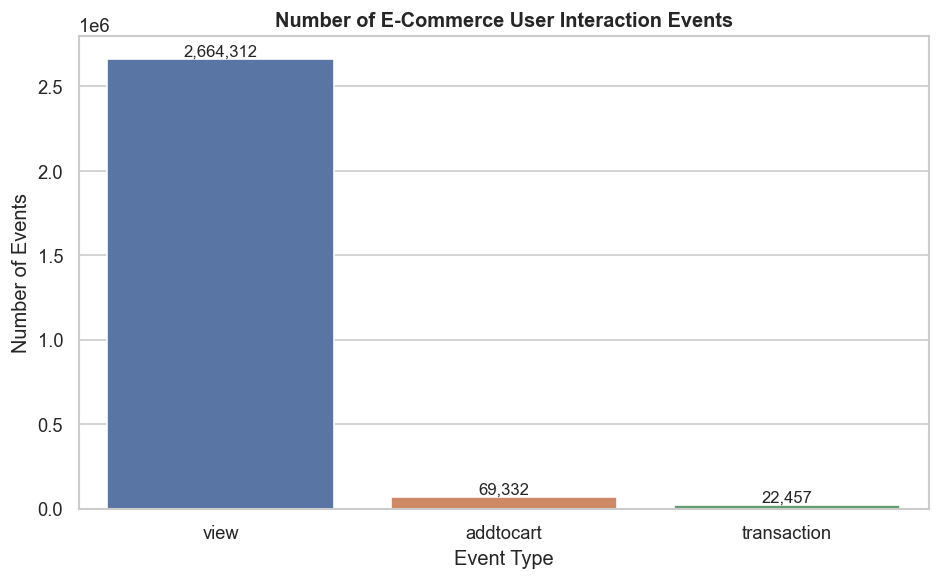

In [9]:
# Purpose: Visualize the number of recorded user interaction events by event type.

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=event_distribution,
    x="event",
    y="count",
    hue="event",
    legend=False
)

plt.title("Number of E-Commerce User Interaction Events")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")

for bar, count in zip(ax.patches, event_distribution["count"]):
    ax.annotate(
        f"{count:,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(
    figures_dir / "01_event_type_counts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [10]:
# Purpose: Calculate the number of unique users, items, and user-item interaction pairs.

dataset_overview = pd.DataFrame({
    "metric": [
        "Total event records",
        "Unique users",
        "Unique items",
        "Unique user-item pairs"
    ],
    "value": [
        len(events_df),
        events_df["visitorid"].nunique(),
        events_df["itemid"].nunique(),
        events_df[["visitorid", "itemid"]].drop_duplicates().shape[0]
    ]
})

display(dataset_overview)

,metric,value
0,Total event records,2756101
1,Unique users,1407580
2,Unique items,235061
3,Unique user-item pairs,2145179


In [11]:
# Purpose: Convert event timestamps to readable dates and determine the dataset time coverage.

events_df["event_datetime"] = pd.to_datetime(
    events_df["timestamp"],
    unit="ms"
)

start_date = events_df["event_datetime"].min()
end_date = events_df["event_datetime"].max()
duration_days = (end_date - start_date).days

print(f"Start date: {start_date}")
print(f"End date: {end_date}")
print(f"Time span: {duration_days:,} days")

Start date: 2015-05-03 03:00:04.384000
End date: 2015-09-18 02:59:47.788000
Time span: 137 days


In [12]:
# Purpose: Create basic temporal features from each event timestamp for exploratory analysis.

events_df["event_date"] = events_df["event_datetime"].dt.date
events_df["event_hour"] = events_df["event_datetime"].dt.hour
events_df["event_dayofweek"] = events_df["event_datetime"].dt.day_name()
events_df["event_month"] = events_df["event_datetime"].dt.month_name()

events_df[
    [
        "timestamp",
        "event_datetime",
        "event_date",
        "event_hour",
        "event_dayofweek",
        "event_month"
    ]
].head()

,timestamp,event_datetime,event_date,event_hour,event_dayofweek,event_month
0,1433221332117,2015-06-02 05:02:12.117,2015-06-02,5,Tuesday,June
1,1433224214164,2015-06-02 05:50:14.164,2015-06-02,5,Tuesday,June
2,1433221999827,2015-06-02 05:13:19.827,2015-06-02,5,Tuesday,June
3,1433221955914,2015-06-02 05:12:35.914,2015-06-02,5,Tuesday,June
4,1433221337106,2015-06-02 05:02:17.106,2015-06-02,5,Tuesday,June


In [13]:
# Purpose: Aggregate daily counts of views, cart additions, and transactions for temporal analysis.

daily_event_counts = (
    events_df
    .groupby(["event_date", "event"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

daily_event_counts["event_date"] = pd.to_datetime(
    daily_event_counts["event_date"]
)

display(daily_event_counts.head())

event,event_date,addtocart,transaction,view
0,2015-05-03,296,83,13304
1,2015-05-04,579,154,18681
2,2015-05-05,565,225,22225
3,2015-05-06,647,258,23015
4,2015-05-07,578,217,22369


In [16]:
# Purpose: Exclude incomplete first and last calendar days from daily trend analysis.

first_date = events_df["event_datetime"].dt.normalize().min()
last_date = events_df["event_datetime"].dt.normalize().max()

daily_event_counts_complete = daily_event_counts[
    (daily_event_counts["event_date"] > first_date) &
    (daily_event_counts["event_date"] < last_date)
].copy()

print(f"First incomplete day excluded: {first_date.date()}")
print(f"Last incomplete day excluded: {last_date.date()}")
print(f"Complete days retained for trend analysis: {len(daily_event_counts_complete)}")

First incomplete day excluded: 2015-05-03
Last incomplete day excluded: 2015-09-18
Complete days retained for trend analysis: 137


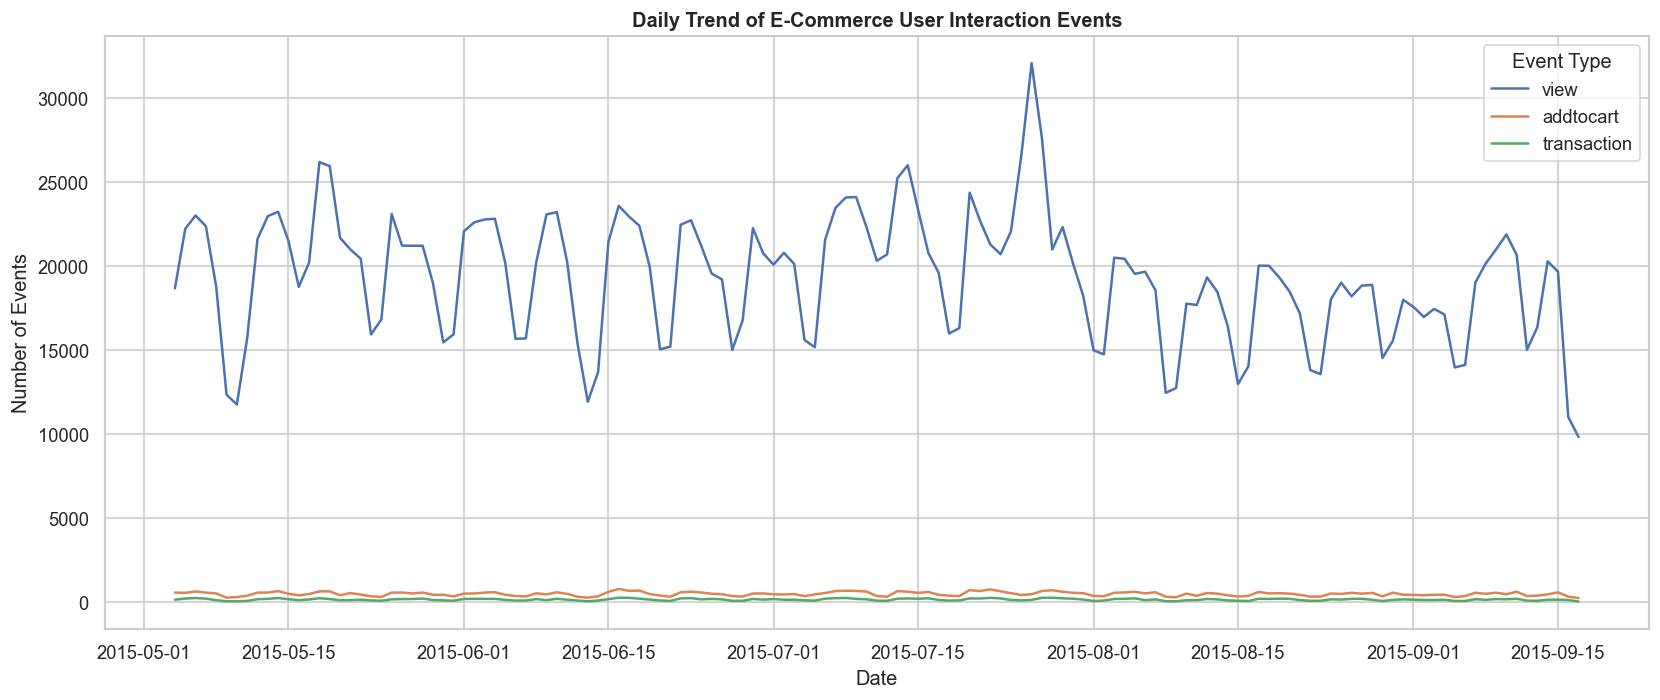

In [17]:
# Purpose: Visualize daily trends in views, cart additions, and transactions over the data period.

plt.figure(figsize=(14, 6))

for event_type in ["view", "addtocart", "transaction"]:
    plt.plot(
        daily_event_counts_complete["event_date"],
        daily_event_counts_complete[event_type],
        label=event_type,
        linewidth=1.5
    )

plt.title("Daily Trend of E-Commerce User Interaction Events")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.legend(title="Event Type")
plt.tight_layout()

plt.savefig(
    figures_dir / "02_daily_event_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

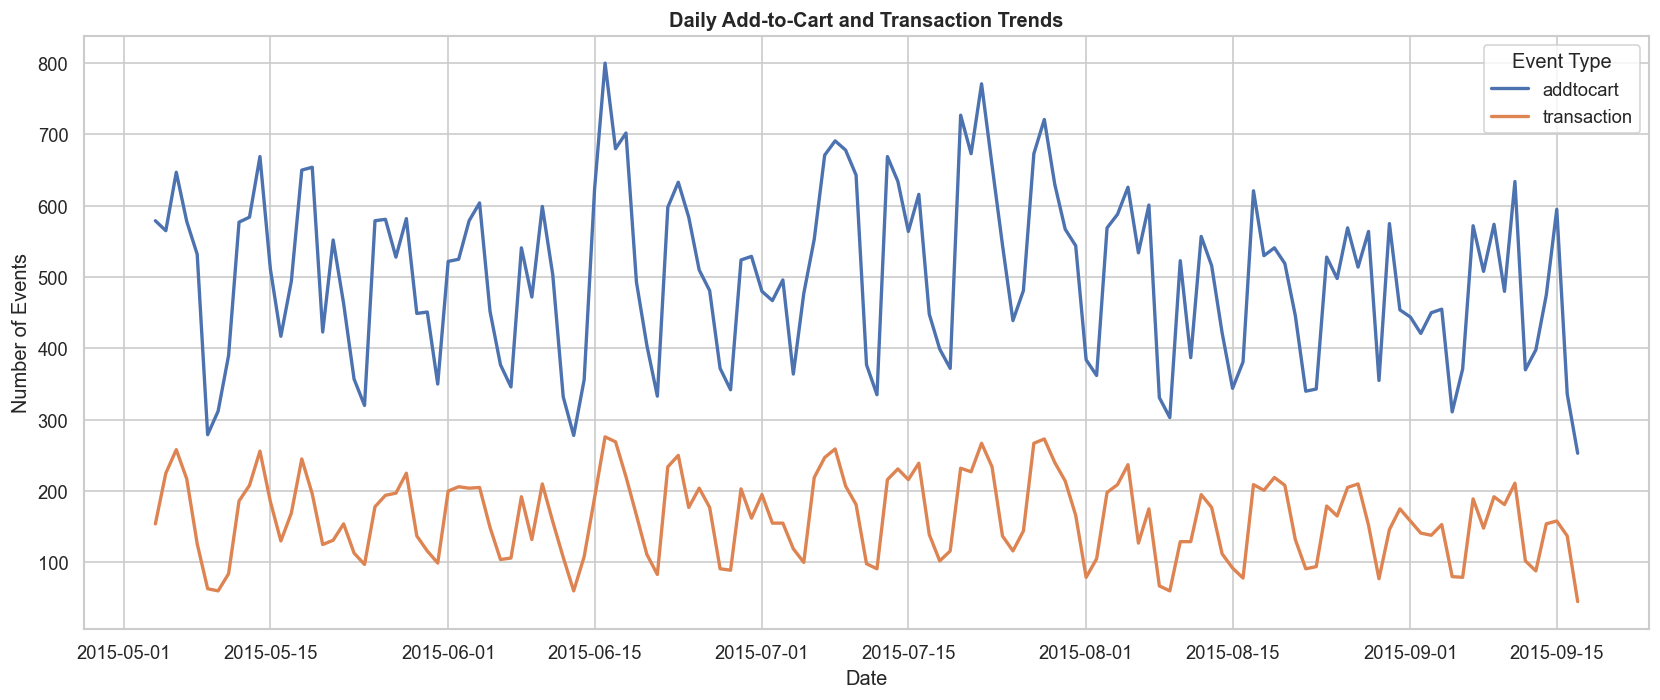

In [18]:
# Purpose: Visualize daily add-to-cart and transaction trends without the dominant view events.

plt.figure(figsize=(14, 6))

for event_type in ["addtocart", "transaction"]:
    plt.plot(
        daily_event_counts_complete["event_date"],
        daily_event_counts_complete[event_type],
        label=event_type,
        linewidth=2
    )

plt.title("Daily Add-to-Cart and Transaction Trends")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.legend(title="Event Type")
plt.tight_layout()

plt.savefig(
    figures_dir / "03_daily_cart_and_transaction_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Purpose: Aggregate event counts for each unique user-item pair to support overlap and conversion-funnel analysis.

user_item_interactions = (
    events_df
    .groupby(["visitorid", "itemid", "event"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for event_type in ["view", "addtocart", "transaction"]:
    if event_type not in user_item_interactions.columns:
        user_item_interactions[event_type] = 0

user_item_interactions = user_item_interactions[
    ["visitorid", "itemid", "view", "addtocart", "transaction"]
]

print("User-item interaction matrix shape:", user_item_interactions.shape)
display(user_item_interactions.head())

User-item interaction matrix shape: (2145179, 5)


event,visitorid,itemid,view,addtocart,transaction
0,0,67045,1,0,0
1,0,285930,1,0,0
2,0,357564,1,0,0
3,1,72028,1,0,0
4,2,216305,2,0,0


In [20]:
# Purpose: Create and save a user-item behavioral funnel table based on whether each interaction type occurred.

funnel_summary = pd.DataFrame({
    "funnel_stage": [
        "User-item pairs with at least one view",
        "User-item pairs with at least one add-to-cart",
        "User-item pairs with at least one transaction"
    ],
    "pair_count": [
        (user_item_interactions["view"] > 0).sum(),
        (user_item_interactions["addtocart"] > 0).sum(),
        (user_item_interactions["transaction"] > 0).sum()
    ]
})

funnel_summary["percentage_of_all_pairs"] = (
    funnel_summary["pair_count"]
    / len(user_item_interactions)
    * 100
).round(2)

funnel_summary.to_csv(
    tables_dir / "01_user_item_behavioral_funnel.csv",
    index=False
)

display(funnel_summary)

,funnel_stage,pair_count,percentage_of_all_pairs
0,User-item pairs with at least one view,2132127,99.390
1,User-item pairs with at least one add-to-cart,62025,2.890
2,User-item pairs with at least one transaction,21270,0.990


In [22]:
# Purpose: Create and save a clearly labeled sequential user-item conversion funnel table.

funnel_summary = pd.DataFrame({
    "funnel_stage": [
        "Viewed item",
        "Viewed item and added it to cart",
        "Viewed item, added it to cart, and purchased it"
    ],
    "pair_count": [
        has_view.sum(),
        (has_view & has_cart).sum(),
        (has_view & has_cart & has_transaction).sum()
    ],
    "percentage_of_viewed_pairs": [
        100.00,
        round((has_view & has_cart).sum() / has_view.sum() * 100, 2),
        round((has_view & has_cart & has_transaction).sum() / has_view.sum() * 100, 2)
    ],
    "percentage_of_previous_stage": [
        np.nan,
        round((has_view & has_cart).sum() / has_view.sum() * 100, 2),
        round(
            (has_view & has_cart & has_transaction).sum()
            / (has_view & has_cart).sum()
            * 100,
            2
        )
    ],
    "previous_stage": [
        "Not applicable",
        "Viewed item",
        "Viewed item and added it to cart"
    ]
})

funnel_summary.to_csv(
    tables_dir / "01_user_item_behavioral_funnel.csv",
    index=False
)

display(funnel_summary)

,funnel_stage,pair_count,percentage_of_viewed_pairs,percentage_of_previous_stage,previous_stage
0,Viewed item,2132127,100.000,NaN,Not applicable
1,Viewed item and added it to cart,49500,2.320,2.320,Viewed item
2,"Viewed item, added it to cart, and purchased it",17353,0.810,35.060,Viewed item and added it to cart


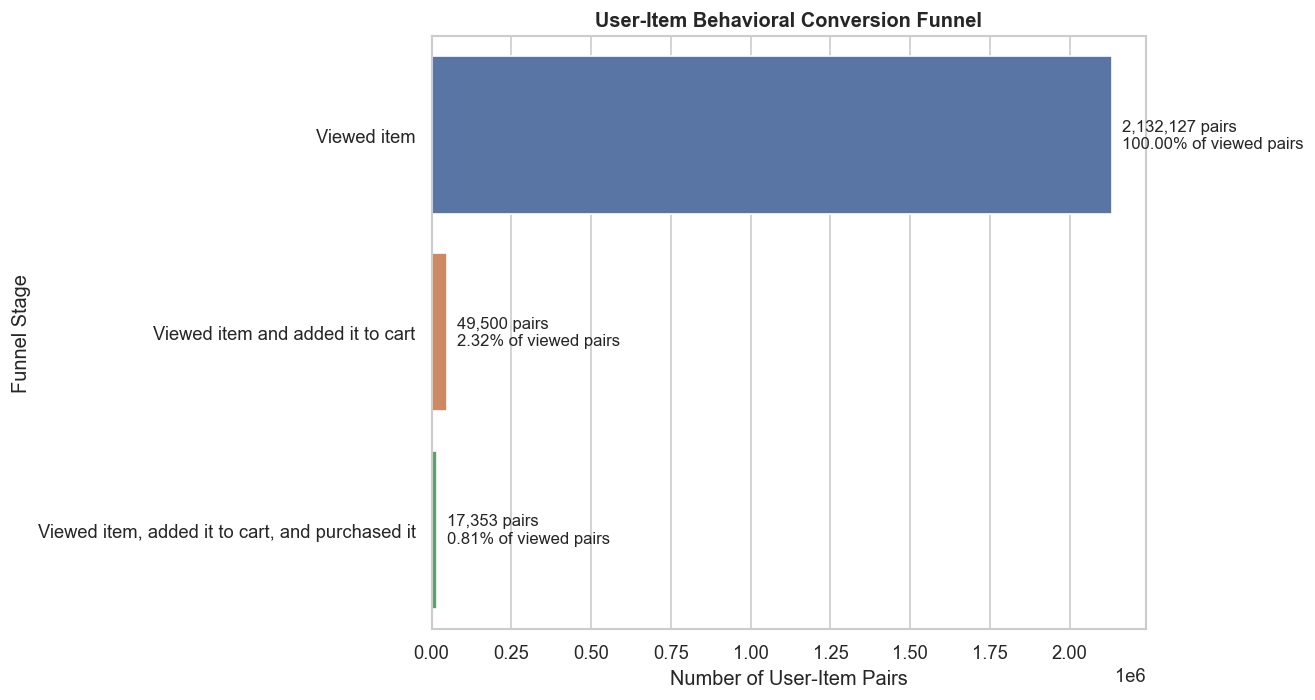

In [24]:
# Purpose: Visualize and save the user-item conversion funnel with counts and view-based conversion rates.

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=funnel_summary,
    y="funnel_stage",
    x="pair_count",
    hue="funnel_stage",
    legend=False
)

plt.title("User-Item Behavioral Conversion Funnel")
plt.xlabel("Number of User-Item Pairs")
plt.ylabel("Funnel Stage")

for bar, count, conversion in zip(
    ax.patches,
    funnel_summary["pair_count"],
    funnel_summary["percentage_of_viewed_pairs"]
):
    ax.annotate(
        f"{count:,} pairs\n{conversion:.2f}% of viewed pairs",
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
        xytext=(6, 0),
        textcoords="offset points"
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "04_user_item_conversion_funnel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Purpose: Summarize the product-category hierarchy and identify root categories.

category_tree_summary = pd.DataFrame({
    "metric": [
        "Total categories",
        "Root categories with no parent",
        "Categories with a parent"
    ],
    "value": [
        category_tree_df["categoryid"].nunique(),
        category_tree_df["parentid"].isna().sum(),
        category_tree_df["parentid"].notna().sum()
    ]
})

display(category_tree_summary)

root_categories = category_tree_df[
    category_tree_df["parentid"].isna()
].copy()

print("\nRoot category IDs:")
display(root_categories)

,metric,value
0,Total categories,1669
1,Root categories with no parent,25
2,Categories with a parent,1644



Root category IDs:


,categoryid,parentid
5,231,NaN
589,791,NaN
861,1490,NaN
939,431,NaN
1111,755,NaN
1142,378,NaN
1208,1579,NaN
1211,1394,NaN
1322,659,NaN
1329,1057,NaN


In [26]:
# Purpose: Summarize how many interaction events each user generated in the dataset.

user_activity = (
    events_df
    .groupby("visitorid")
    .size()
    .rename("event_count")
    .reset_index()
)

user_activity_summary = user_activity["event_count"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="value")

display(user_activity_summary)

,value
count,"1,407,580.000"
mean,1.958
std,12.580
min,1.000
25%,1.000
50%,1.000
75%,2.000
90%,3.000
95%,5.000
99%,13.000


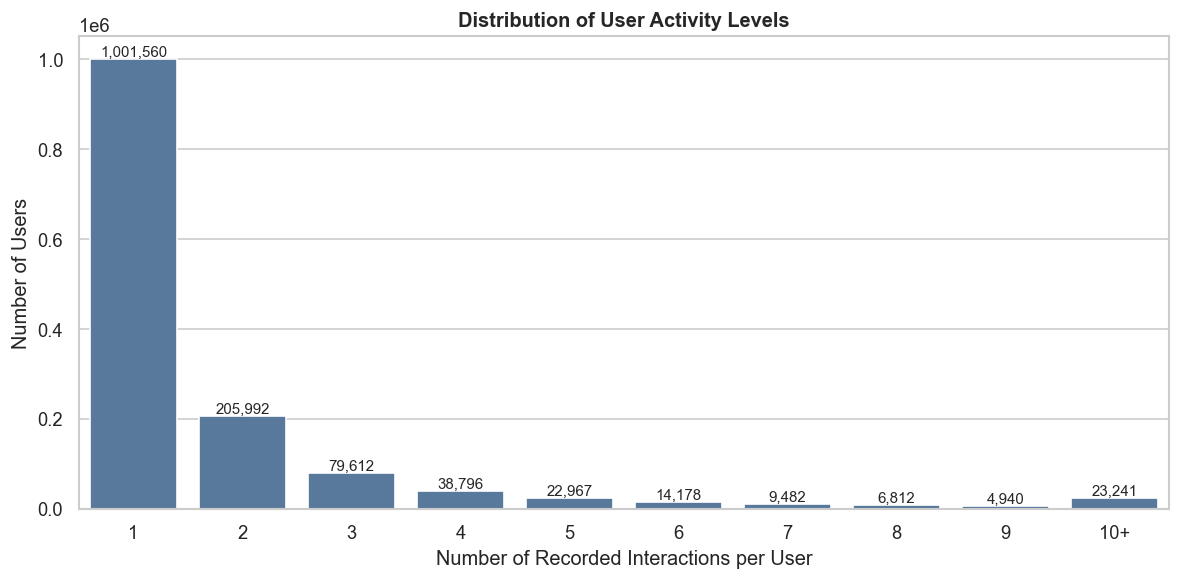

In [27]:
# Purpose: Visualize and save the distribution of event counts for users with up to 10 recorded interactions.

user_activity_plot = user_activity.copy()

user_activity_plot["interaction_group"] = np.where(
    user_activity_plot["event_count"] >= 10,
    "10+",
    user_activity_plot["event_count"].astype(str)
)

interaction_distribution = (
    user_activity_plot["interaction_group"]
    .value_counts()
    .reindex([str(i) for i in range(1, 10)] + ["10+"])
    .reset_index()
)

interaction_distribution.columns = ["interaction_count", "user_count"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=interaction_distribution,
    x="interaction_count",
    y="user_count",
    color="#4C78A8"
)

plt.title("Distribution of User Activity Levels")
plt.xlabel("Number of Recorded Interactions per User")
plt.ylabel("Number of Users")

for bar, count in zip(ax.patches, interaction_distribution["user_count"]):
    ax.annotate(
        f"{count:,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "05_user_activity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Purpose: Summarize how many user interaction events each item received in the dataset.

item_activity = (
    events_df
    .groupby("itemid")
    .size()
    .rename("event_count")
    .reset_index()
)

item_activity_summary = item_activity["event_count"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="value")

display(item_activity_summary)

,value
count,"235,061.000"
mean,11.725
std,37.032
min,1.000
25%,1.000
50%,3.000
75%,9.000
90%,25.000
95%,47.000
99%,143.000


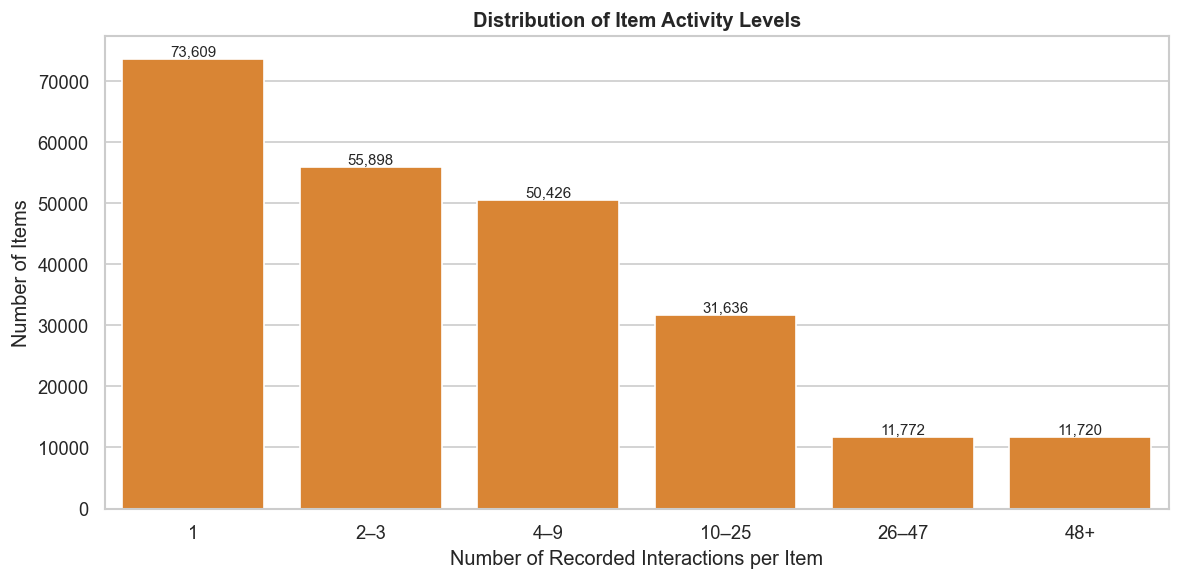

In [29]:
# Purpose: Visualize and save the distribution of item activity using interpretable event-count groups.

item_activity_plot = item_activity.copy()

item_activity_plot["activity_group"] = pd.cut(
    item_activity_plot["event_count"],
    bins=[0, 1, 3, 9, 25, 47, np.inf],
    labels=["1", "2–3", "4–9", "10–25", "26–47", "48+"]
)

item_activity_distribution = (
    item_activity_plot["activity_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

item_activity_distribution.columns = ["event_count_group", "item_count"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=item_activity_distribution,
    x="event_count_group",
    y="item_count",
    color="#F58518"
)

plt.title("Distribution of Item Activity Levels")
plt.xlabel("Number of Recorded Interactions per Item")
plt.ylabel("Number of Items")

for bar, count in zip(ax.patches, item_activity_distribution["item_count"]):
    ax.annotate(
        f"{count:,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "06_item_activity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Purpose: Quantify repeated interactions between the same user and item.

total_events = len(events_df)
unique_user_item_pairs = len(user_item_interactions)
repeated_event_records = total_events - unique_user_item_pairs

interaction_repetition_summary = pd.DataFrame({
    "metric": [
        "Total event records",
        "Unique user-item pairs",
        "Repeated event records beyond the first pair interaction",
        "Percentage of repeated event records"
    ],
    "value": [
        total_events,
        unique_user_item_pairs,
        repeated_event_records,
        round(repeated_event_records / total_events * 100, 2)
    ]
})

display(interaction_repetition_summary)

,metric,value
0,Total event records,"2,756,101.000"
1,Unique user-item pairs,"2,145,179.000"
2,Repeated event records beyond the first pair i...,"610,922.000"
3,Percentage of repeated event records,22.170


In [31]:
# Purpose: Summarize the number of users, items, and transactions associated with completed purchases.

transaction_events = events_df[
    events_df["event"] == "transaction"
].copy()

purchase_summary = pd.DataFrame({
    "metric": [
        "Transaction event records",
        "Unique purchasing users",
        "Unique purchased items",
        "Unique purchaser-item pairs"
    ],
    "value": [
        len(transaction_events),
        transaction_events["visitorid"].nunique(),
        transaction_events["itemid"].nunique(),
        transaction_events[["visitorid", "itemid"]].drop_duplicates().shape[0]
    ]
})

display(purchase_summary)

,metric,value
0,Transaction event records,22457
1,Unique purchasing users,11719
2,Unique purchased items,12025
3,Unique purchaser-item pairs,21270


In [32]:
# Purpose: Summarize how many transaction events each purchasing user generated.

purchases_per_user = (
    transaction_events
    .groupby("visitorid")
    .size()
    .rename("transaction_count")
    .reset_index()
)

purchases_per_user_summary = purchases_per_user["transaction_count"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="value")

display(purchases_per_user_summary)

,value
count,"11,719.000"
mean,1.916
std,8.851
min,1.000
25%,1.000
50%,1.000
75%,1.000
90%,2.000
95%,4.000
99%,13.000


In [34]:
# Purpose: Measure co-occurrence of view, cart, and transaction events within purchaser-item pairs.

purchase_path_summary = pd.DataFrame({
    "purchase_path": [
        "All purchaser-item pairs",
        "Purchased pairs also having at least one recorded view",
        "Purchased pairs also having recorded view and add-to-cart"
    ],
    "pair_count": [
        has_transaction.sum(),
        (has_transaction & has_view).sum(),
        (has_transaction & has_view & has_cart).sum()
    ]
})

purchase_path_summary["percentage_of_all_purchased_pairs"] = (
    purchase_path_summary["pair_count"]
    / purchase_path_summary.loc[0, "pair_count"]
    * 100
).round(2)

display(purchase_path_summary)

,purchase_path,pair_count,percentage_of_all_purchased_pairs
0,All purchaser-item pairs,21270,100.000
1,Purchased pairs also having at least one recor...,19051,89.570
2,Purchased pairs also having recorded view and ...,17353,81.580


In [35]:
# Purpose: Calculate the first recorded time of each event type for every user-item pair.

user_item_first_event_times = (
    events_df
    .groupby(["visitorid", "itemid", "event"])["event_datetime"]
    .min()
    .unstack()
    .reset_index()
)

for event_type in ["view", "addtocart", "transaction"]:
    if event_type not in user_item_first_event_times.columns:
        user_item_first_event_times[event_type] = pd.NaT

user_item_first_event_times = user_item_first_event_times[
    ["visitorid", "itemid", "view", "addtocart", "transaction"]
]

display(user_item_first_event_times.head())

event,visitorid,itemid,view,addtocart,transaction
0,0,67045,2015-09-11 20:55:17.175,NaT,NaT
1,0,285930,2015-09-11 20:49:49.439,NaT,NaT
2,0,357564,2015-09-11 20:52:39.591,NaT,NaT
3,1,72028,2015-08-13 17:46:06.444,NaT,NaT
4,2,216305,2015-08-07 18:01:08.920,NaT,NaT


In [36]:
# Purpose: Identify and save purchaser-item pairs that follow a true temporal view-to-cart-to-purchase sequence.

purchased_event_times = user_item_first_event_times[
    user_item_first_event_times["transaction"].notna()
].copy()

view_before_transaction = (
    purchased_event_times["view"].notna()
    & (purchased_event_times["view"] < purchased_event_times["transaction"])
)

view_cart_transaction_sequence = (
    purchased_event_times["view"].notna()
    & purchased_event_times["addtocart"].notna()
    & (purchased_event_times["view"] < purchased_event_times["addtocart"])
    & (purchased_event_times["addtocart"] < purchased_event_times["transaction"])
)

temporal_purchase_funnel = pd.DataFrame({
    "funnel_stage": [
        "All purchaser-item pairs",
        "View recorded before transaction",
        "View recorded before cart, and cart recorded before transaction"
    ],
    "pair_count": [
        len(purchased_event_times),
        view_before_transaction.sum(),
        view_cart_transaction_sequence.sum()
    ]
})

temporal_purchase_funnel["percentage_of_all_purchased_pairs"] = (
    temporal_purchase_funnel["pair_count"]
    / temporal_purchase_funnel.loc[0, "pair_count"]
    * 100
).round(2)

temporal_purchase_funnel.to_csv(
    tables_dir / "02_temporal_purchase_path_summary.csv",
    index=False
)

display(temporal_purchase_funnel)

,funnel_stage,pair_count,percentage_of_all_purchased_pairs
0,All purchaser-item pairs,21270,100.000
1,View recorded before transaction,18738,88.100
2,"View recorded before cart, and cart recorded b...",16497,77.560


In [37]:
# Purpose: Create and save the article-ready temporal conversion funnel across all user-item pairs.

has_view_time = user_item_first_event_times["view"].notna()

view_before_cart = (
    user_item_first_event_times["view"].notna()
    & user_item_first_event_times["addtocart"].notna()
    & (
        user_item_first_event_times["view"]
        < user_item_first_event_times["addtocart"]
    )
)

view_cart_before_transaction = (
    user_item_first_event_times["view"].notna()
    & user_item_first_event_times["addtocart"].notna()
    & user_item_first_event_times["transaction"].notna()
    & (
        user_item_first_event_times["view"]
        < user_item_first_event_times["addtocart"]
    )
    & (
        user_item_first_event_times["addtocart"]
        < user_item_first_event_times["transaction"]
    )
)

temporal_funnel_summary = pd.DataFrame({
    "funnel_stage": [
        "Viewed item",
        "Viewed item before adding it to cart",
        "Viewed item before cart, and cart before purchase"
    ],
    "pair_count": [
        has_view_time.sum(),
        view_before_cart.sum(),
        view_cart_before_transaction.sum()
    ],
    "percentage_of_viewed_pairs": [
        100.00,
        round(view_before_cart.sum() / has_view_time.sum() * 100, 2),
        round(
            view_cart_before_transaction.sum()
            / has_view_time.sum()
            * 100,
            2
        )
    ],
    "percentage_of_previous_stage": [
        np.nan,
        round(view_before_cart.sum() / has_view_time.sum() * 100, 2),
        round(
            view_cart_before_transaction.sum()
            / view_before_cart.sum()
            * 100,
            2
        )
    ]
})

temporal_funnel_summary.to_csv(
    tables_dir / "01_user_item_behavioral_funnel.csv",
    index=False
)

display(temporal_funnel_summary)

,funnel_stage,pair_count,percentage_of_viewed_pairs,percentage_of_previous_stage
0,Viewed item,2132127,100.000,NaN
1,Viewed item before adding it to cart,45390,2.130,2.130
2,"Viewed item before cart, and cart before purchase",16497,0.770,36.350


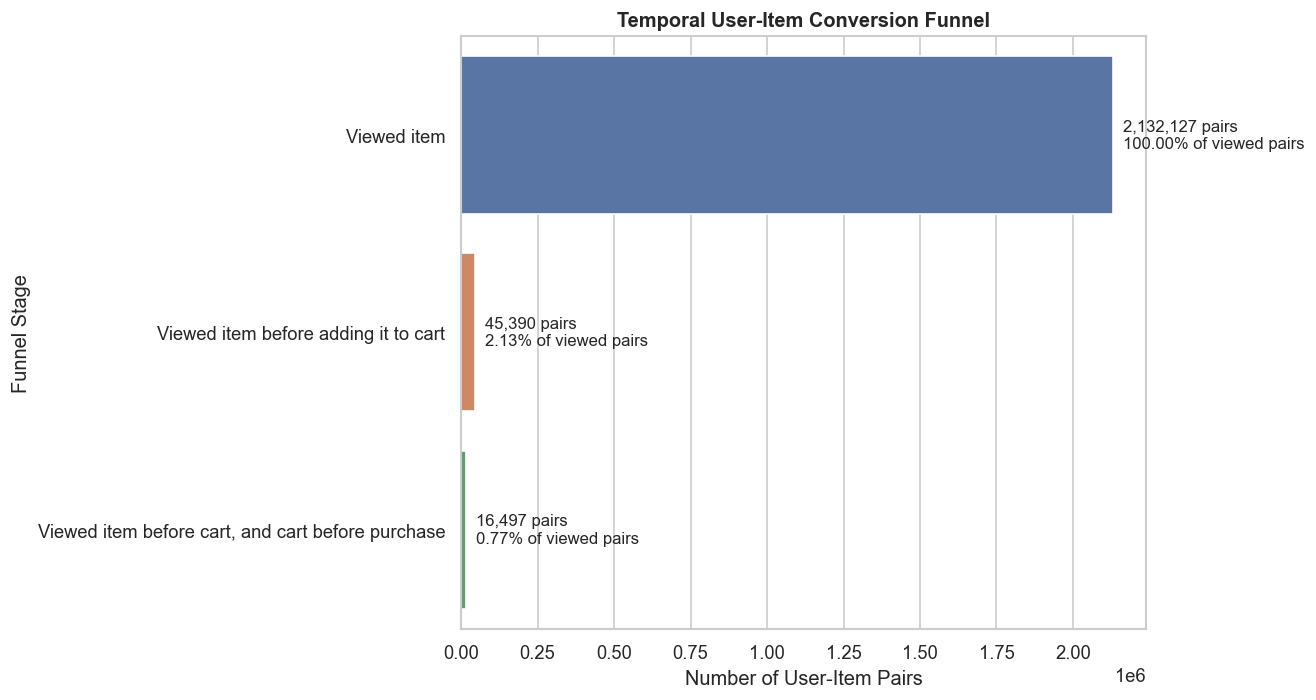

In [38]:
# Purpose: Visualize and save the article-ready temporal user-item conversion funnel.

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=temporal_funnel_summary,
    y="funnel_stage",
    x="pair_count",
    hue="funnel_stage",
    legend=False
)

plt.title("Temporal User-Item Conversion Funnel")
plt.xlabel("Number of User-Item Pairs")
plt.ylabel("Funnel Stage")

for bar, count, conversion in zip(
    ax.patches,
    temporal_funnel_summary["pair_count"],
    temporal_funnel_summary["percentage_of_viewed_pairs"]
):
    ax.annotate(
        f"{count:,} pairs\n{conversion:.2f}% of viewed pairs",
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
        xytext=(6, 0),
        textcoords="offset points"
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "04_temporal_user_item_conversion_funnel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Purpose: Aggregate the number of user interaction events by hour of day.

hourly_event_counts = (
    events_df
    .groupby(["event_hour", "event"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
    .reset_index()
)

display(hourly_event_counts)

event,event_hour,addtocart,transaction,view
0,0,3725,1119,139459
1,1,3578,1037,136087
2,2,3337,1012,141530
3,3,3266,836,146758
4,4,3141,747,143296
5,5,2786,747,116039
6,6,1803,477,74692
7,7,1028,278,42638
8,8,540,106,24663
9,9,399,70,17440


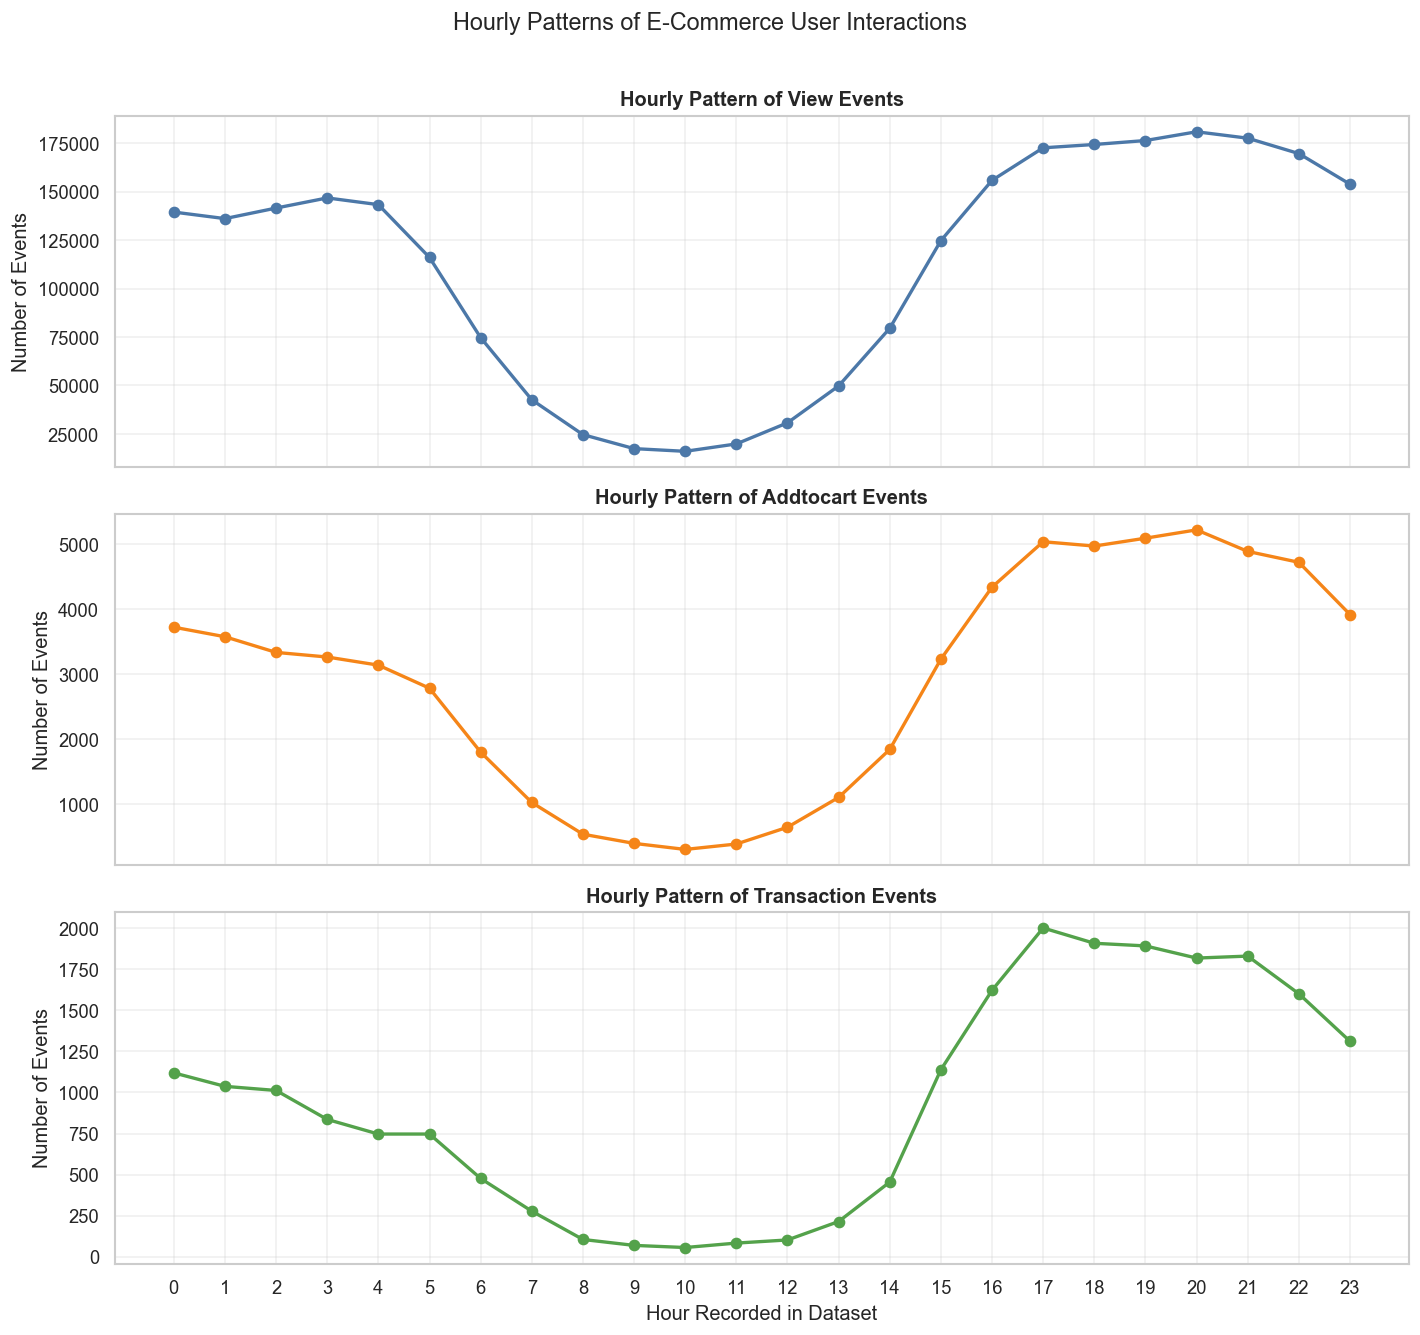

In [40]:
# Purpose: Visualize and save hourly patterns separately for views, cart additions, and transactions.

event_types = ["view", "addtocart", "transaction"]
colors = ["#4C78A8", "#F58518", "#54A24B"]

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for ax, event_type, color in zip(axes, event_types, colors):
    ax.plot(
        hourly_event_counts["event_hour"],
        hourly_event_counts[event_type],
        marker="o",
        linewidth=2,
        color=color
    )
    ax.set_title(f"Hourly Pattern of {event_type.title()} Events")
    ax.set_ylabel("Number of Events")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Hour Recorded in Dataset")
axes[-1].set_xticks(range(24))

fig.suptitle("Hourly Patterns of E-Commerce User Interactions", y=1.01, fontsize=14)
plt.tight_layout()

plt.savefig(
    figures_dir / "07_hourly_interaction_patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
# Purpose: Aggregate user interaction events by day of week in chronological order.

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_event_counts = (
    events_df
    .groupby(["event_dayofweek", "event"])
    .size()
    .unstack(fill_value=0)
    .reindex(weekday_order, fill_value=0)
    .reset_index()
)

display(weekday_event_counts)

event,event_dayofweek,addtocart,transaction,view
0,Monday,11371,3848,424594
1,Tuesday,11585,3973,431519
2,Wednesday,11384,4151,415579
3,Thursday,10951,3750,404060
4,Friday,9545,2929,367225
5,Saturday,6949,1811,296455
6,Sunday,7547,1995,324880


In [42]:
# Purpose: Calculate average daily event counts by weekday using only complete calendar days.

weekday_daily_average = daily_event_counts_complete.copy()

weekday_daily_average["event_dayofweek"] = (
    weekday_daily_average["event_date"]
    .dt.day_name()
)

weekday_daily_average = (
    weekday_daily_average
    .groupby("event_dayofweek")[["view", "addtocart", "transaction"]]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

complete_days_per_weekday = (
    daily_event_counts_complete
    .assign(
        event_dayofweek=lambda df: df["event_date"].dt.day_name()
    )
    .groupby("event_dayofweek")["event_date"]
    .nunique()
    .reindex(weekday_order)
    .reset_index(name="complete_day_count")
)

weekday_daily_average = weekday_daily_average.merge(
    complete_days_per_weekday,
    on="event_dayofweek",
    how="left"
)

weekday_daily_average[
    ["event_dayofweek", "complete_day_count", "view", "addtocart", "transaction"]
] = weekday_daily_average[
    ["event_dayofweek", "complete_day_count", "view", "addtocart", "transaction"]
].round(2)

display(weekday_daily_average)

,event_dayofweek,view,addtocart,transaction,complete_day_count
0,Monday,"21,229.700",568.550,192.400,20
1,Tuesday,"21,575.950",579.250,198.650,20
2,Wednesday,"20,778.950",569.200,207.550,20
3,Thursday,"20,203.000",547.550,187.500,20
4,Friday,"19,249.790",500.580,153.370,19
5,Saturday,"15,602.890",365.740,95.320,19
6,Sunday,"16,398.740",381.630,100.630,19


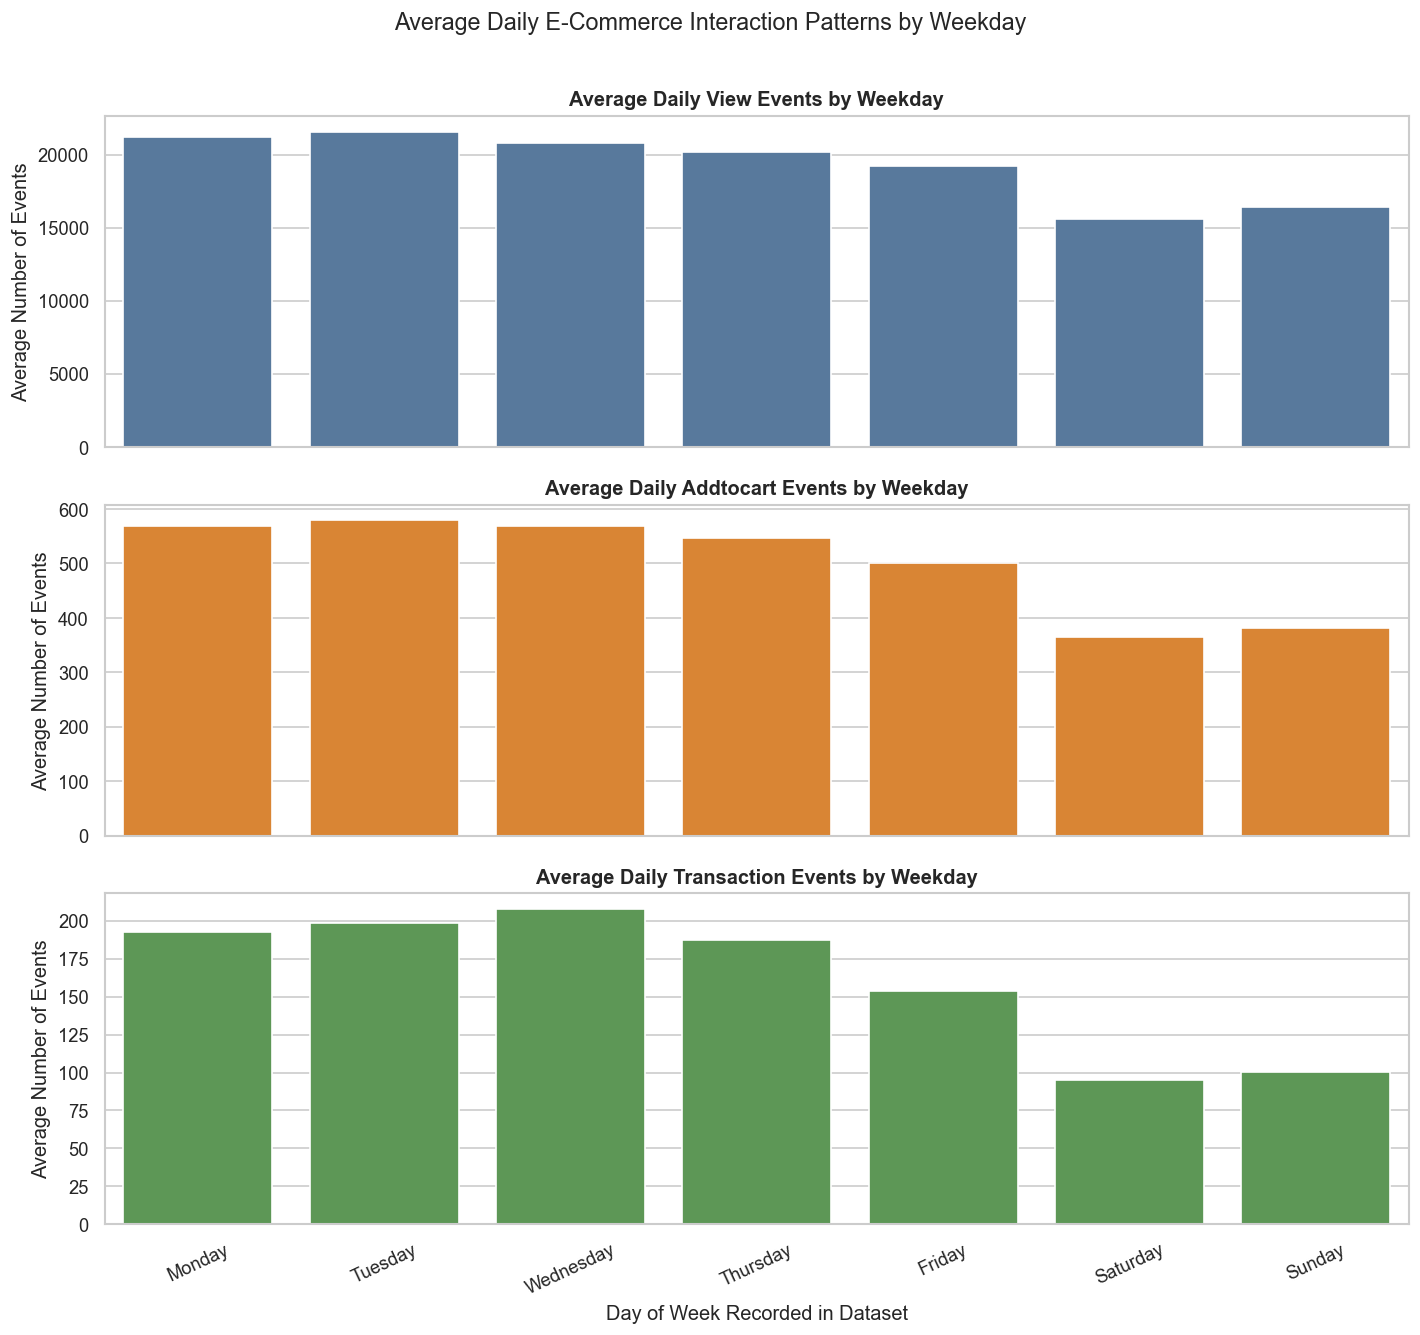

In [43]:
# Purpose: Visualize and save the average daily event counts by weekday for each interaction type.

event_types = ["view", "addtocart", "transaction"]
colors = ["#4C78A8", "#F58518", "#54A24B"]

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for ax, event_type, color in zip(axes, event_types, colors):
    sns.barplot(
        data=weekday_daily_average,
        x="event_dayofweek",
        y=event_type,
        color=color,
        ax=ax
    )
    ax.set_title(f"Average Daily {event_type.title()} Events by Weekday")
    ax.set_xlabel("")
    ax.set_ylabel("Average Number of Events")
    ax.tick_params(axis="x", rotation=25)

axes[-1].set_xlabel("Day of Week Recorded in Dataset")

fig.suptitle(
    "Average Daily E-Commerce Interaction Patterns by Weekday",
    y=1.01,
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    figures_dir / "08_weekday_interaction_patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# Purpose: Perform final raw-data quality checks for duplicates and invalid key values.

final_quality_checks = pd.DataFrame({
    "check": [
        "Exact duplicate rows in events dataset",
        "Exact duplicate rows in category tree dataset",
        "Missing visitor IDs in events dataset",
        "Missing item IDs in events dataset",
        "Invalid event labels in events dataset",
        "Duplicate category IDs in category tree dataset"
    ],
    "value": [
        events_df.duplicated().sum(),
        category_tree_df.duplicated().sum(),
        events_df["visitorid"].isna().sum(),
        events_df["itemid"].isna().sum(),
        (~events_df["event"].isin(["view", "addtocart", "transaction"])).sum(),
        category_tree_df["categoryid"].duplicated().sum()
    ]
})

display(final_quality_checks)

,check,value
0,Exact duplicate rows in events dataset,460
1,Exact duplicate rows in category tree dataset,0
2,Missing visitor IDs in events dataset,0
3,Missing item IDs in events dataset,0
4,Invalid event labels in events dataset,0
5,Duplicate category IDs in category tree dataset,0


In [45]:
# Purpose: Save the data-quality audit table and create a deduplicated event dataset for later notebooks.

final_quality_checks.to_csv(
    tables_dir / "03_raw_data_quality_checks.csv",
    index=False
)

raw_event_columns = [
    "timestamp",
    "visitorid",
    "event",
    "itemid",
    "transactionid"
]

events_cleaned_df = (
    events_df[raw_event_columns]
    .drop_duplicates()
    .copy()
)

cleaned_events_path = processed_data_dir / "events_cleaned.csv"

events_cleaned_df.to_csv(
    cleaned_events_path,
    index=False
)

print(f"Raw event records: {len(events_df):,}")
print(f"Cleaned event records: {len(events_cleaned_df):,}")
print(f"Removed exact duplicates: {len(events_df) - len(events_cleaned_df):,}")
print(f"\nSaved cleaned file to: {cleaned_events_path}")

Raw event records: 2,756,101
Cleaned event records: 2,755,641
Removed exact duplicates: 460

Saved cleaned file to: F:\ecommerce-recommender-xai\data\processed\events_cleaned.csv


In [46]:
# Purpose: Create and save an article-ready summary table of the datasets and cleaned event data.

dataset_characteristics = pd.DataFrame({
    "characteristic": [
        "Raw event records",
        "Cleaned event records",
        "Exact duplicate event records removed",
        "Unique users",
        "Unique items",
        "Unique user-item pairs",
        "Transaction event records",
        "Unique purchasing users",
        "Product categories",
        "Root product categories",
        "Observation period",
        "Number of calendar days covered"
    ],
    "value": [
        f"{len(events_df):,}",
        f"{len(events_cleaned_df):,}",
        f"{len(events_df) - len(events_cleaned_df):,}",
        f"{events_df['visitorid'].nunique():,}",
        f"{events_df['itemid'].nunique():,}",
        f"{len(user_item_interactions):,}",
        f"{len(transaction_events):,}",
        f"{transaction_events['visitorid'].nunique():,}",
        f"{category_tree_df['categoryid'].nunique():,}",
        f"{category_tree_df['parentid'].isna().sum():,}",
        f"{start_date.date()} to {end_date.date()}",
        f"{duration_days:,}"
    ]
})

dataset_characteristics.to_csv(
    tables_dir / "04_dataset_characteristics.csv",
    index=False
)

display(dataset_characteristics)

,characteristic,value
0,Raw event records,"2,756,101"
1,Cleaned event records,"2,755,641"
2,Exact duplicate event records removed,460
3,Unique users,"1,407,580"
4,Unique items,"235,061"
5,Unique user-item pairs,"2,145,179"
6,Transaction event records,"22,457"
7,Unique purchasing users,"11,719"
8,Product categories,"1,669"
9,Root product categories,25


## Purpose: Summarize the main findings of the data audit and define implications for later modeling.

### Data Audit Conclusions

- The cleaned dataset contains 2,755,641 valid event records from 1,407,580 users and 235,061 items.
- User and item interactions are highly sparse and long-tailed; therefore, cold-start-aware recommendation strategies will be required.
- Purchase events are rare relative to views, so purchase-prediction evaluation must prioritize Precision, Recall, F1-score, and PR-AUC rather than Accuracy alone.
- The temporally valid user-item funnel confirms that the main conversion bottleneck is the transition from product view to add-to-cart.
- Repeated interactions account for 22.17% of all event records and should be retained as behavioral signals in feature engineering.
- Only 460 exact duplicate event records were removed; no missing user or item identifiers and no invalid event labels were detected.